|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>What, why, when, and how to layernorm<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Demo of numerical instabilities

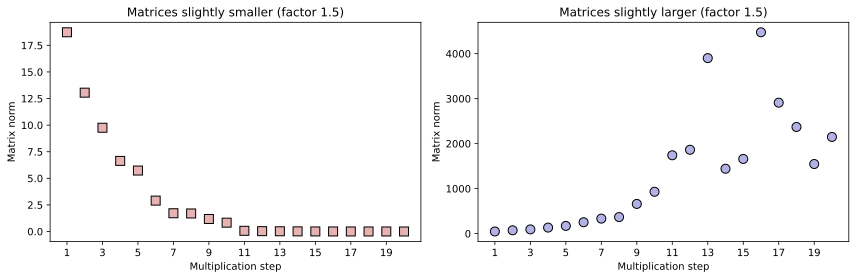

In [2]:
# scaling factor
scalefact = 1.5

# number of multiplications
nummults = 20

# initialize random matrices
Asmol = torch.randn(30,30)
Abig  = torch.randn(30,30)

# initialize results
norms = torch.zeros(nummults,2)

# loop over N multiplications
for i in range(nummults):
  Asmol *= torch.randn(30,30) * (1/scalefact)
  norms[i,0] = torch.norm(Asmol)

  Abig *= torch.randn(30,30) * scalefact
  norms[i,1] = torch.norm(Abig)


# draw the plots
_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].plot(range(1,nummults+1),norms[:,0],'ks',markersize=9,markerfacecolor=[.9,.7,.7])
axs[1].plot(range(1,nummults+1),norms[:,1],'ko',markersize=9,markerfacecolor=[.7,.7,.9])

for a,t in zip(axs,['smaller','larger']):
  a.set(xticks=range(1,nummults+1,2),xlabel='Multiplication step',ylabel='Matrix norm',title=f'Matrices slightly {t} (factor {scalefact})')

plt.tight_layout()
plt.show()

# Create a matrix (activations matrix)

In [3]:
n_in  =  3
n_out = 10

A = torch.randn(n_in,n_out)*2 + 3
torch.round(A)

tensor([[-0.,  2.,  1.,  6.,  8.,  3.,  1.,  5.,  1.,  0.],
        [ 4.,  5.,  5.,  2., -2.,  3.,  3.,  1.,  1.,  0.],
        [ 5.,  3.,  4.,  2.,  1.,  4., -0.,  0.,  3.,  3.]])

# Create a LayerNorm object instance

In [4]:
layernorm = nn.LayerNorm(n_out)# repeat with (n_in,n_out)
layernorm

LayerNorm((10,), eps=1e-05, elementwise_affine=True)

# Apply layernorm to the weights matrix

In [5]:
normA = layernorm(A)

print('Original matrix:\n',torch.round(A))
print('\nLayer-normed matrix:\n',torch.round(normA))

Original matrix:
 tensor([[-0.,  2.,  1.,  6.,  8.,  3.,  1.,  5.,  1.,  0.],
        [ 4.,  5.,  5.,  2., -2.,  3.,  3.,  1.,  1.,  0.],
        [ 5.,  3.,  4.,  2.,  1.,  4., -0.,  0.,  3.,  3.]])

Layer-normed matrix:
 tensor([[-1., -0., -1.,  1.,  2., -0., -1.,  1., -1., -1.],
        [ 1.,  1.,  1., -0., -2.,  0.,  1., -1., -1., -1.],
        [ 1.,  0.,  1., -0., -1.,  1., -2., -1.,  0.,  1.]],
       grad_fn=<RoundBackward0>)


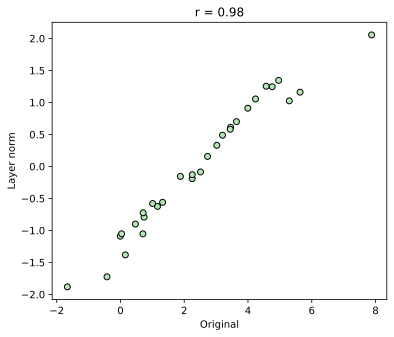

In [6]:
# how does layernorm change the matrix?

# convenience variables
a1 = A.detach().flatten()
a2 = normA.detach().flatten()

# correlation between them
r = torch.sum( (a1-a1.mean()) * (a2-a2.mean()) )
r /= torch.sqrt( torch.sum((a1-a1.mean())**2) * torch.sum((a2-a2.mean())**2) )

# scatter plot!
plt.figure(figsize=(6,5))
plt.plot(a1,a2,'ko',markerfacecolor=[.7,.9,.7])

# labels etc
plt.gca().set(xlabel='Original',ylabel='Layer norm',
              title=f'r = {r:.2f}')
plt.show()

In [7]:
print('ORIGINAL: mean across columns for each row:')
print(f'  {torch.mean(A,axis=1)}\n')
print('LAYERNORM: mean across columns for each row:')
print(f'  {torch.mean(normA,axis=1).detach()}\n')


print('ORIGINAL: std across columns for each row:')
print(f'  {torch.std(A,axis=1)}\n')
print('LAYERNORM: std across columns for each row:')
print(f'  {torch.std(normA,axis=1).detach()}\n')


print('\n\nLAYERNORM: mean across rows for each column:')
print(f'  {torch.mean(normA,axis=0).detach()}\n')
print('LAYERNORM: std across rows for each column:')
print(f'  {torch.std(normA,axis=0).detach()}\n')

ORIGINAL: mean across columns for each row:
  tensor([2.7252, 2.1984, 2.4683])

LAYERNORM: mean across columns for each row:
  tensor([5.9605e-08, 1.0729e-07, 9.5367e-08])

ORIGINAL: std across columns for each row:
  tensor([2.6413, 2.1649, 1.7663])

LAYERNORM: std across columns for each row:
  tensor([1.0541, 1.0541, 1.0541])



LAYERNORM: mean across rows for each column:
  tensor([ 0.2884,  0.4954,  0.4550,  0.2923, -0.2930,  0.4859, -0.5792, -0.3601,
        -0.3276, -0.4571])

LAYERNORM: std across rows for each column:
  tensor([1.2255, 0.7808, 1.0925, 0.7524, 2.0761, 0.5703, 1.1694, 1.2442, 0.4198,
        0.9027])



# Inspect the layernorm parameters

In [8]:
print(f"Value of 'gamma' (stretch/scale param): {layernorm.weight}\n")
print(f"Value of 'beta': (shift param): {layernorm.bias}\n")

Value of 'gamma' (stretch/scale param): Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], requires_grad=True)

Value of 'beta': (shift param): Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)



# Modify the layernorm params and reapply to data

In [9]:
layernorm.weight = torch.nn.Parameter(torch.ones(n_out)*3)
layernorm.bias = torch.nn.Parameter(torch.ones(n_out)*5)

layernorm.weight

Parameter containing:
tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3.], requires_grad=True)

In [10]:
normAnew = layernorm(A)

print('ORIGINAL: mean across columns for each row:')
print(f'  {torch.mean(A,axis=1)}\n')
print('ORIGINAL: std across columns for each row:')
print(f'  {torch.std(A,axis=1)}\n')

print('NEW LAYERNORM: mean across columns for each row:')
print(f'  {torch.mean(normAnew,axis=1).detach()}\n')
print('NEW LAYERNORM: std across columns for each row:')
print(f'  {torch.std(normAnew,axis=1).detach()}\n')

ORIGINAL: mean across columns for each row:
  tensor([2.7252, 2.1984, 2.4683])

ORIGINAL: std across columns for each row:
  tensor([2.6413, 2.1649, 1.7663])

NEW LAYERNORM: mean across columns for each row:
  tensor([5., 5., 5.])

NEW LAYERNORM: std across columns for each row:
  tensor([3.1623, 3.1623, 3.1623])

